# Define your region

If you are working on an administrative region within the European Union, you can use the following code snippets to explore the NUTS (nomenclature of territorial units for statistics) regions. 

## Download NUTS regions

In [16]:
import zipfile
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path

# Create a data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Create regions subdirectory
regions_dir = data_dir / 'regions'
regions_dir.mkdir(exist_ok=True)

# Download NUTS admin region shapefiles if not already present
nuts_zip = regions_dir / 'NUTS_RG_20M_2024_4326.shp.zip'
if not nuts_zip.exists():
    import subprocess
    print("Downloading NUTS admin region shapefiles...")
    subprocess.run(['wget', 'https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2024_4326.shp.zip',
                    '-O', str(nuts_zip)], check=True)
    
    # Unzip the file
    print("Unzipping shapefiles...")
    with zipfile.ZipFile(nuts_zip, 'r') as zip_ref:
        zip_ref.extractall(regions_dir / 'NUTS_RG_20M_2024_4326')

# Read NUTS shapefiles
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)


In [17]:
print((nuts_gdf['NAME_LATN'] == "Molise").any())

True


### Select your region

We extract the NUTS2 region with the name "Molise" as an example

In [18]:
admin_name = "Molise"

if (nuts_gdf['NAME_LATN'] == "Molise").any():
    admin_id = nuts_gdf[nuts_gdf['NAME_LATN'] == "Molise"]['NUTS_ID'].values[0]
    print(f"Found {admin_name} region with ID: {admin_id}")
else:
    print(f"Region {admin_name} not found in NUTS dataset.")

# Filter for region
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Found {admin_id} region: {sel_gdf.geometry.total_bounds}")


Found Molise region with ID: ITF2
Found ITF2 region: [13.94103834 41.38256335 15.13817868 42.07005936]


<Axes: >

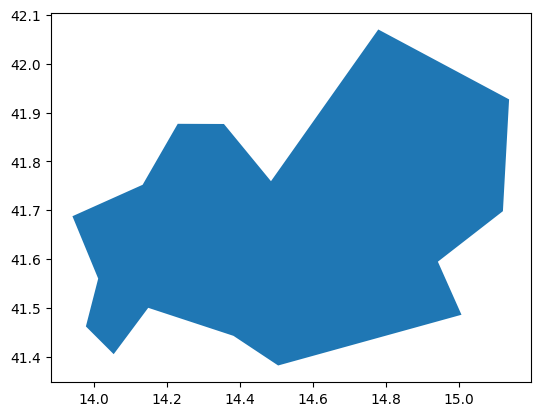

In [19]:
sel_gdf.plot()


You don't know which NUTS ID you need?
Checkout this interactive map: [Exploring NUTS Regions](../tutorials/explore_nuts_regions)
